# Résultats K-NN naïf

### Un modèle globlal

Entraînement du K-NN...
--- RÉSULTATS BASELINE K-NN ---
MAE: 0.1102
RMSE : 0.1575
nRMSE : 39.47%


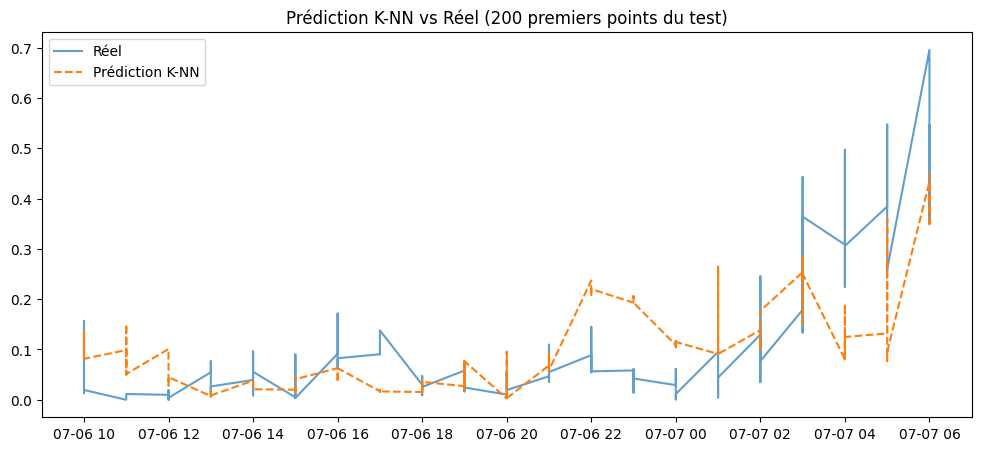

In [ ]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import matplotlib.pyplot as plt
from tools import DataProcessor
processor = DataProcessor(path_folder="./data")
df = processor.run()
df = df.dropna()
df = df.sort_values("delivery_time")


split_idx = int(len(df) * 0.8)
train_df = df.iloc[:split_idx]
test_df = df.iloc[split_idx:]

cols_to_drop = [
    "delivery_time",
    "production_normalized",
    "site_name",
    "production_lag1",  
    "production_lag24",  
    "production_rolling_mean_24",
    "production_rolling_std_24",
    "production_rolling_mean_168",
    "production_rolling_std_168"
]

X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
y_train = train_df["production_normalized"]
X_test = test_df.drop(columns=cols_to_drop, errors='ignore')
y_test = test_df["production_normalized"]
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsRegressor(n_neighbors=25, n_jobs=-1))
])

knn_pipeline.fit(X_train, y_train)

preds = knn_pipeline.predict(X_test)
mae = mean_absolute_error(y_test, preds)
rmse = root_mean_squared_error(y_test, preds)
nrmse = (rmse / y_test.mean()) * 100

print(f"--- RÉSULTATS BASELINE K-NN ---")
print(f"MAE: {mae:.4f}")
print(f"RMSE : {rmse:.4f}")
print(f"nRMSE : {nrmse:.2f}%")

plt.figure(figsize=(12, 5))
plt.plot(test_df["delivery_time"][:200], y_test[:200], label="Réel", alpha=0.7)
plt.plot(test_df["delivery_time"][:200], preds[:200], label="Prédiction K-NN", ls='--')
plt.legend()
plt.title("Prédiction K-NN vs Réel (200 premiers points du test)")
plt.show()

### Un modèle par site

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error
import pandas as pd
import numpy as np

processor = DataProcessor(path_folder="./data", drop_columns=[])
df_all = processor.run().dropna()

site_models = {}
site_results = []

unique_sites = df_all["site_name"].unique()
print(f"Début de l'entraînement pour {len(unique_sites)} sites...\n")

for site_name, df_site in df_all.groupby("site_name"):
    df_site = df_site.sort_values("delivery_time")
    
    split_idx = int(len(df_site) * 0.8)
    train_df = df_site.iloc[:split_idx]
    test_df = df_site.iloc[split_idx:]

    cols_to_drop = [
        "delivery_time", 
        "production_normalized", 
        "site_name",
        "production_lag1",  
        "production_lag24",  
        "production_rolling_mean_24",
        "production_rolling_std_24",
        "production_rolling_mean_168",
        "production_rolling_std_168"
    ]

    X_train = train_df.drop(columns=cols_to_drop, errors='ignore')
    y_train = train_df["production_normalized"]

    X_test = test_df.drop(columns=cols_to_drop, errors='ignore')
    y_test = test_df["production_normalized"]
    
    knn_site = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsRegressor(n_neighbors=25, n_jobs=-1))
    ])
    
    knn_site.fit(X_train, y_train)

    preds = knn_site.predict(X_test)
    
    mae = mean_absolute_error(y_test, preds)
    rmse = root_mean_squared_error(y_test, preds)
    mean_val = y_test.mean()
    nrmse = (rmse / mean_val) * 100 if mean_val != 0 else 0
    
    site_models[site_name] = knn_site
    site_results.append({
        "Site": site_name,
        "MAE": round(mae, 4),
        "RMSE": round(rmse, 4),
        "nRMSE (%)": round(nrmse, 2)
    })
    
    print(f" Site {site_name} terminé (nRMSE: {nrmse:.2f}%)")

df_summary = pd.DataFrame(site_results)
print("\n" + "="*30)
print("   RÉSULTATS PAR SITE")
print("="*30)
print(df_summary.sort_values("nRMSE (%)", ascending=True).to_string(index=False))

print("\n" + "-"*30)
print(f"MAE moyen global : {df_summary['MAE'].mean():.2f}")
print(f"RMSE moyen global : {df_summary['RMSE'].mean():.2f}")
print(f"nRMSE moyen global : {df_summary['nRMSE (%)'].mean():.2f}%")
print("-"*30)

Début de l'entraînement pour 10 sites...

 Site Belwind Phase 1 terminé (nRMSE: 34.91%)
 Site Mermaid Offshore WP terminé (nRMSE: 32.44%)
 Site Nobelwind Offshore Windpark terminé (nRMSE: 31.79%)
 Site Norther Offshore WP terminé (nRMSE: 36.05%)
 Site Northwester 2 terminé (nRMSE: 41.86%)
 Site Northwind terminé (nRMSE: 34.22%)
 Site Rentel Offshore WP terminé (nRMSE: 32.90%)
 Site Seastar Offshore WP terminé (nRMSE: 33.56%)
 Site Thorntonbank - C-Power - Area NE terminé (nRMSE: 38.48%)
 Site Thorntonbank - C-Power - Area SW terminé (nRMSE: 34.69%)

   RÉSULTATS PAR SITE
                            Site    MAE   RMSE  nRMSE (%)
     Nobelwind Offshore Windpark 0.1018 0.1398      31.79
             Mermaid Offshore WP 0.1091 0.1437      32.44
              Rentel Offshore WP 0.0959 0.1313      32.90
             Seastar Offshore WP 0.1017 0.1397      33.56
                       Northwind 0.0994 0.1373      34.22
Thorntonbank - C-Power - Area SW 0.0946 0.1313      34.69
                